# Mudanças

Foi encotrado durante o projeto de "Workflow & Experimento" um encoder chamado `TargetEncoder` que substitui cada categoria pela média da variável alvo (target) correspondente a essa categoria.

**Isso é ótimo** pois não altera a dimensionalidade do dataset e mantém uma relação linear, ideal para modelos com o KNN.

Tendo isso em vista foi feita uma análise das entregas passadas, substituindo o `BinaryEncoder` e o `FrequencyEncoder` pelo `TargetEncoder` para comparar  os resultados e houve realmente uma melhora substancial no resultado.

- Principal Alterção: `TargetEncoder` substituiu o `BinaryEncoder` e `FrequencyEncoder`, além de que o `QuantileTransformer(Uniform)` subsitutiu o `RobustScaler`.

> Informações detalhadas no relatório.

# 0. Inicialização Geral

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/CD/AcidentesPorOcorrencia_entrega3.csv")

print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

Mounted at /content/drive
Dataset carregado: 83817 linhas, 18 colunas


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83817 entries, 0 to 83816
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dia_semana              83817 non-null  object 
 1   uf                      83817 non-null  object 
 2   km                      83817 non-null  float64
 3   causa_acidente          83817 non-null  object 
 4   tipo_acidente           83817 non-null  object 
 5   classificacao_acidente  83817 non-null  object 
 6   fase_dia                83817 non-null  object 
 7   sentido_via             83817 non-null  object 
 8   condicao_metereologica  83817 non-null  object 
 9   tipo_pista              83817 non-null  object 
 10  tracado_via             83817 non-null  object 
 11  uso_solo                83817 non-null  object 
 12  ignorados               83817 non-null  int64  
 13  veiculos                83817 non-null  int64  
 14  latitude                83817 non-null

In [ ]:
contagem_classes = df['classificacao_acidente'].value_counts()
print(contagem_classes)

print("\n=======================\n")

porcentagem_classes = (df['classificacao_acidente'].value_counts(normalize=True) * 100).round(2)
print(porcentagem_classes)

classificacao_acidente
Com Vítimas Feridas    64992
Sem Vítimas            12853
Com Vítimas Fatais      5972
Name: count, dtype: int64


classificacao_acidente
Com Vítimas Feridas    77.54
Sem Vítimas            15.33
Com Vítimas Fatais      7.13
Name: proportion, dtype: float64


## Configurações do Novo Modelo

In [ ]:
!pip -q install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from category_encoders import TargetEncoder

In [ ]:
# === 1. Ordinal Encoder ===
class OrdinalFaseDiaEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ordem = {'Pleno dia': 0, 'Amanhecer': 1, 'Anoitecer': 2, 'Plena Noite': 3}

    def fit(self, X, y=None):
        return self # Não precisa aprender nada do treino, a regra é estática

    def transform(self, X):
        X = X.copy()
        X['fase_dia'] = X['fase_dia'].map(self.ordem)
        return X

# === 2. Cyclic Encoder ===
class CyclicDiaSemanaEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ordem = {'segunda-feira': 0, 'terça-feira': 1, 'quarta-feira': 2,
                      'quinta-feira': 3, 'sexta-feira': 4, 'sábado': 5, 'domingo': 6}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['dia_semana_num'] = X['dia_semana'].str.lower().map(self.ordem)
        X['dia_semana_sin'] = np.sin(2 * np.pi * X['dia_semana_num'] / 7)
        X['dia_semana_cos'] = np.cos(2 * np.pi * X['dia_semana_num'] / 7)
        return X.drop(columns=['dia_semana', 'dia_semana_num'])

In [ ]:
# Definindo as colunas
colunas_te = ['tracado_via', 'tipo_acidente', 'sentido_via', 'condicao_metereologica', 'uso_solo', 'tipo_pista', 'uf', 'causa_acidente']
colunas_escalar = ['km', 'veiculos', 'latitude', 'longitude', 'mes', 'hora', 'dia_semana_sin', 'dia_semana_cos']

# Criando o pré-processador para o Scaler (Utilizando o melhor avaliado (novo) - QuantileTransformer(uniform))
scaler_step = ColumnTransformer(
    transformers=[
        ('Quantile(uniform)', QuantileTransformer(output_distribution='uniform', random_state=42), colunas_escalar)
    ],
    remainder='passthrough'
)

# Classificador com ajuste de peso por distância
pipeline_knn = Pipeline(steps=[
    ('ordinal_fase_dia', OrdinalFaseDiaEncoder()),
    ('cyclic_dia_semana', CyclicDiaSemanaEncoder()),
    ('target_encoder', TargetEncoder(cols=colunas_te)),
    ('scaler', scaler_step)
])

# Para selecionar as 10 features do MI
pipeline_knn.named_steps['scaler'].set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('Quantile(uniform)',
                                 QuantileTransformer(random_state=42),
                                 ['km', 'veiculos', 'latitude', 'longitude',
                                  'mes', 'hora', 'dia_semana_sin',
                                  'dia_semana_cos'])])

In [ ]:
X = df.drop(columns=['classificacao_acidente'])
y = df['classificacao_acidente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_enc = pipeline_knn.fit_transform(X_train, y_train)
X_test_enc = pipeline_knn.transform(X_test)

colunas_mi = ['remainder__tipo_acidente', 'remainder__causa_acidente', 'Quantile(uniform)__latitude', 'Quantile(uniform)__longitude', 'remainder__ignorados', 'Quantile(uniform)__veiculos', 'remainder__uso_solo', 'remainder__fase_dia', 'Quantile(uniform)__hora', 'remainder__uf']
X_train_mi = X_train_enc[colunas_mi]
X_test_mi = X_test_enc[colunas_mi]

# 1. Verificar desbalanceamento nos dados

In [ ]:
# Contagem em y_train
print("Contagem em y_train:")
print(pd.Series(y_train).value_counts())

# Contagem em y_test
print("\nContagem em y_test:")
print(pd.Series(y_test).value_counts())

print("\n=======================\n")

# Exibindo y_train em %
print("Proporção em y_train:")
print((pd.Series(y_train).value_counts(normalize=True) * 100).round(2))

# Exibindo y_test em %
print("\nProporção em y_test:")
print((pd.Series(y_test).value_counts(normalize=True) * 100).round(2))

Contagem em y_train:
classificacao_acidente
Com Vítimas Feridas    51993
Sem Vítimas            10282
Com Vítimas Fatais      4778
Name: count, dtype: int64

Contagem em y_test:
classificacao_acidente
Com Vítimas Feridas    12999
Sem Vítimas             2571
Com Vítimas Fatais      1194
Name: count, dtype: int64


Proporção em y_train:
classificacao_acidente
Com Vítimas Feridas    77.54
Sem Vítimas            15.33
Com Vítimas Fatais      7.13
Name: proportion, dtype: float64

Proporção em y_test:
classificacao_acidente
Com Vítimas Feridas    77.54
Sem Vítimas            15.34
Com Vítimas Fatais      7.12
Name: proportion, dtype: float64


## Resultados

> Como era de se esperar pelo uso do parâmetro `stratify = y`,  a proporção se mantém no conjunto de treino e teste.

Temos um nítido desbalanceamento de dados presente nesse dataset, com +77% representando uma única classe e apenas 7% representando a classe mais importante para o modelo, "Com Vítimas Fatais".

Aspecto interessante é que a classe de "Sem Vítimas" não é a mais dominante, mesmo que seja a que ocorre com maior frequência na realidade, isso provavelmente se deve a subnotificação de casos desse tipo, onde o entendimento entre os envolvidos ocorrem sem acionamento de autoridades.

- Esse desbalanceamento justifica o uso do *F1-Score*, visto que a acurácia seria extremamente ilusória na avaliação do modelo, além do uso do *Recall* muito importe para avaliar o quanto o modelo identifica a situação mais crítica que são os acidentes fatais.

# 2. Aplicar técnicas de balanceamento (oversampling/undersampling)

In [ ]:
# Mudança para o Pipeline do Imbalanced Learning para prevenção de Data Leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Classificador Baseline (Encoder, Scaler e Feature Selection)
pipeline_knn_base = ImbPipeline(steps=[
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1))
])

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.37      0.19      0.25      1194
Com Vítimas Feridas       0.82      0.94      0.88     12999
        Sem Vítimas       0.68      0.33      0.44      2571

           accuracy                           0.80     16764
          macro avg       0.62      0.49      0.53     16764
       weighted avg       0.77      0.80      0.77     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


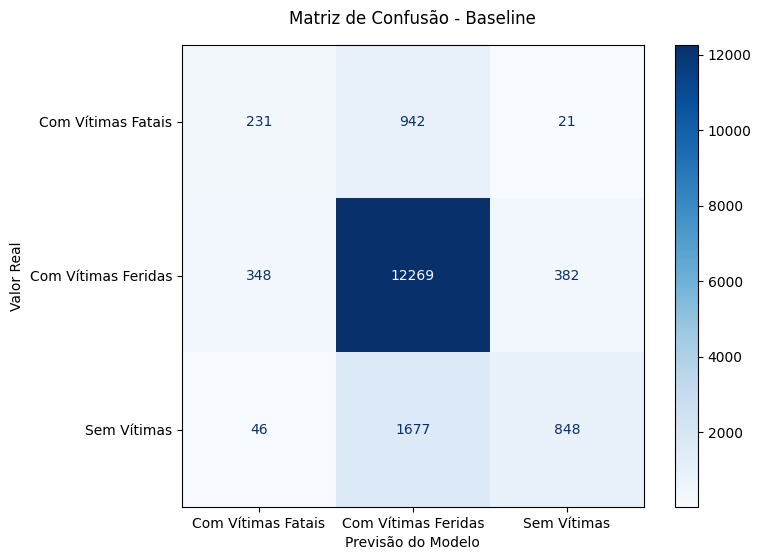

In [ ]:
# Onde o Resampling vai agir
pipeline_knn_base.fit(X_train_mi, y_train)

# As previsões são feitas no conjunto de teste que não tem Resampling
y_pred = pipeline_knn_base.predict(X_test_mi)

# Validação dos resultados
print(classification_report(y_test, y_pred))

print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm_pca = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=pipeline_knn_base.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Baseline', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

## 2.1 Balanceamento com Ajuste no Algoritmo

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.35      0.18      0.24      1194
Com Vítimas Feridas       0.83      0.93      0.87     12999
        Sem Vítimas       0.58      0.35      0.44      2571

           accuracy                           0.79     16764
          macro avg       0.59      0.49      0.52     16764
       weighted avg       0.75      0.79      0.76     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


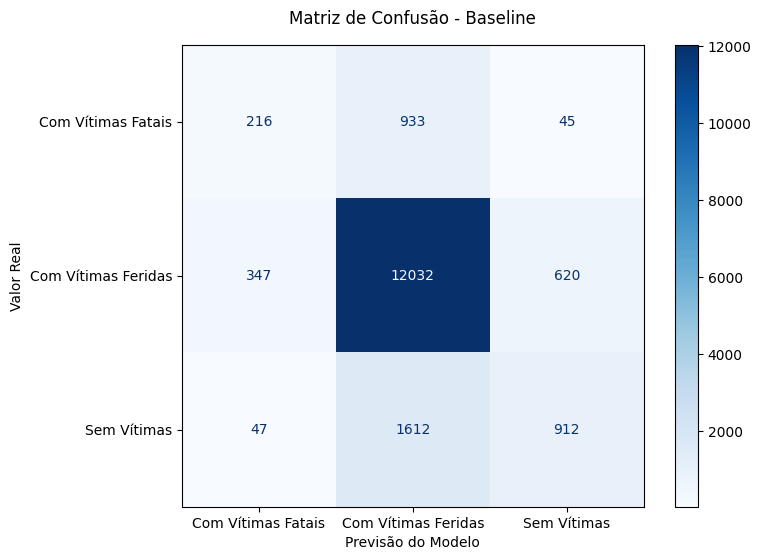

In [ ]:
# Classificador apenas com Weights
pipeline_knn_weights = ImbPipeline(steps=[
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1, weights='distance'))
])

pipeline_knn_weights.fit(X_train_mi, y_train)
y_pred = pipeline_knn_weights.predict(X_test_mi)

# Validação dos resultados
print(classification_report(y_test, y_pred))

print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm_pca = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=pipeline_knn_weights.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Baseline', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

## Resultados

É normal que o `weights='distance'` sozinho piore o resultado (nesse caso, mantido muito parecido, com uma leve queda no F1-score de Fatais de 0.25 para 0.24).

Isso ocorre, pois ao usar pesos por distância em um dataset muito desbalanceado, se um ponto da classe minoritária estiver cercado por vários pontos da classe majoritária, mesmo que ele esteja ligeiramente mais próximo de um ou dois vizinhos da sua própria classe, a soma dos pesos inversos da distância da vizinhança majoritária sufoca a classe rara.

## 2.2 Balanceamento com OverSampling (SMOTE)

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.18      0.50      0.27      1194
Com Vítimas Feridas       0.86      0.60      0.71     12999
        Sem Vítimas       0.32      0.54      0.40      2571

           accuracy                           0.59     16764
          macro avg       0.46      0.55      0.46     16764
       weighted avg       0.73      0.59      0.63     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


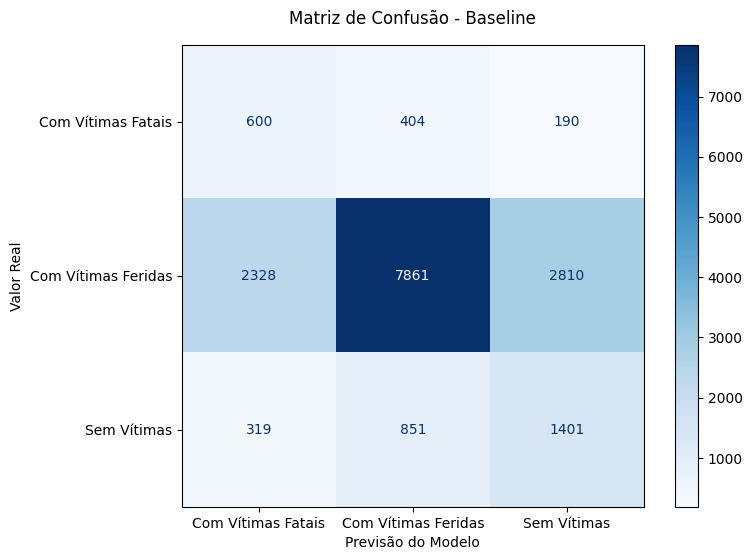

In [ ]:
# Classificador com OverSampling (apenas SMOTE)
pipeline_knn_smote = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1))
])

pipeline_knn_smote.fit(X_train_mi, y_train)
y_pred = pipeline_knn_smote.predict(X_test_mi)

# Validação dos resultados
print(classification_report(y_test, y_pred))

print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm_pca = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=pipeline_knn_smote.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Baseline', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.19      0.46      0.27      1194
Com Vítimas Feridas       0.86      0.64      0.73     12999
        Sem Vítimas       0.33      0.53      0.41      2571

           accuracy                           0.61     16764
          macro avg       0.46      0.55      0.47     16764
       weighted avg       0.73      0.61      0.65     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


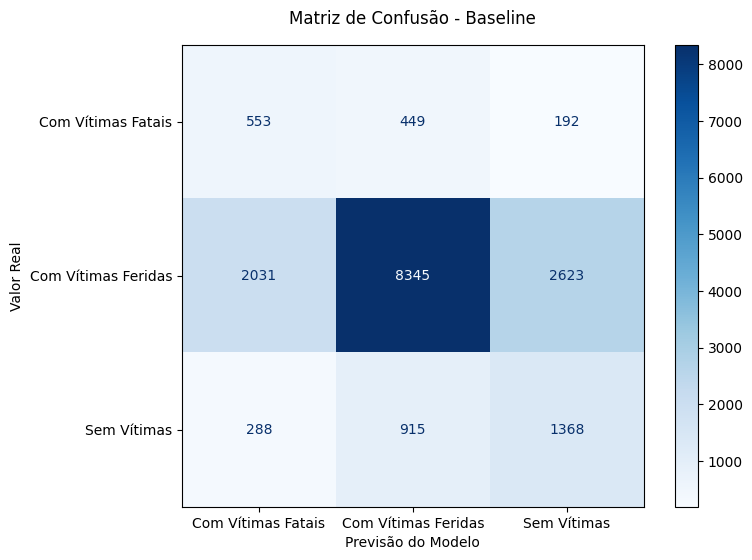

In [ ]:
# Classificador com OverSampling (SMOTE + Weights)
pipeline_knn_smote_w = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1, weights='distance'))
])

pipeline_knn_smote_w.fit(X_train_mi, y_train)
y_pred = pipeline_knn_smote_w.predict(X_test_mi)

# Validação dos resultados
print(classification_report(y_test, y_pred))

print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm_pca = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=pipeline_knn_smote_w.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Baseline', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

## Resultados

### Comparação com Baseline

- O *Recall* de `Com Vítimas Fatais` saltou de 0.19 para 0.50 (no *SMOTE* puro) e 0.46 (com *Weights*). Isso significa que o modelo agora captura cerca de metade dos acidentes letais, o que é um avanço gigantesco em termos de segurança viária.

- A *Precisão* de `Com Vítimas Fatais` despencou para 0.18 / 0.19.
  - Significa que, a cada 100 acidentes que o modelo aponta como "Fatais", apenas cerca de 19 realmente são. O modelo ficou "paranoico": na dúvida, ele classifica como fatal.

> Para conseguir enxergar as classes minoritárias, o modelo sacrificou a classe majoritária (Com Vítimas Feridas), cujo Recall caiu de 0.94 para a faixa dos 0.60.

### SMOTE Puro vs SMOTE + Weights

- O modelo com Weights recuperou um pouco do Recall de Vítimas Feridas (0.64 contra 0.60) sem destruir o ganho das outras classes.

- A acurácia geral do modelo com *Weights* subiu de 0.59 (*SMOTE* Puro) para 0.61 e a média ponderada (Weighted Avg) do F1-Score subiu de 0.63 para 0.65.

> Podemos dizer que o modelo com *Weights* se saiu ligeiramente melhor.

## 2.3 Balanceamento com UnderSampling

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.16      0.69      0.26      1194
Com Vítimas Feridas       0.87      0.53      0.66     12999
        Sem Vítimas       0.35      0.50      0.41      2571

           accuracy                           0.54     16764
          macro avg       0.46      0.57      0.45     16764
       weighted avg       0.74      0.54      0.60     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


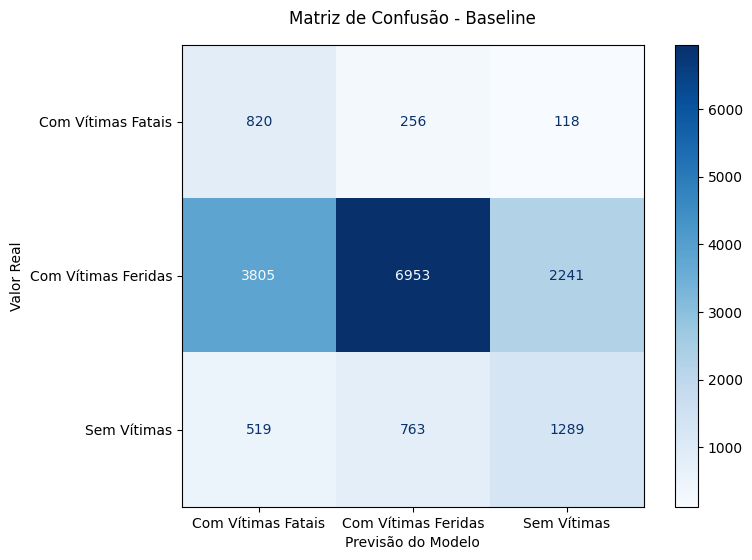

In [ ]:
# Classificador de Resampling (apenas Undersampling)
pipeline_knn_under = ImbPipeline(steps=[
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1))
])

pipeline_knn_under.fit(X_train_mi, y_train)
y_pred = pipeline_knn_under.predict(X_test_mi)

# Validação dos resultados
print(classification_report(y_test, y_pred))

print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm_pca = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=pipeline_knn_under.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Baseline', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.18      0.62      0.27      1194
Com Vítimas Feridas       0.87      0.52      0.65     12999
        Sem Vítimas       0.30      0.55      0.39      2571

           accuracy                           0.54     16764
          macro avg       0.45      0.57      0.44     16764
       weighted avg       0.73      0.54      0.59     16764


=== GERANDO MATRIZ DE CONFUSÃO ===


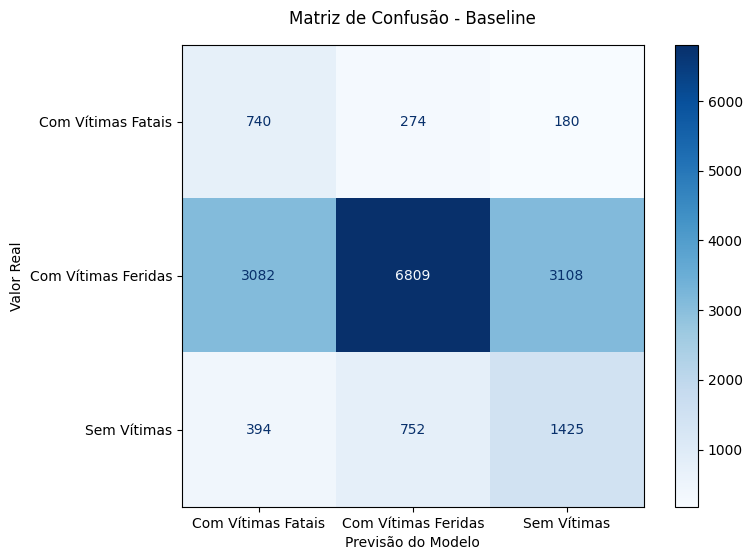

In [ ]:
# Classificador de Resampling (Undersampling + Weights)
pipeline_knn_under_w = ImbPipeline(steps=[
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1, weights='distance'))
])

pipeline_knn_under_w.fit(X_train_mi, y_train)
y_pred = pipeline_knn_under_w.predict(X_test_mi)

# Validação dos resultados
print(classification_report(y_test, y_pred))

print("\n=== GERANDO MATRIZ DE CONFUSÃO ===")
cm_pca = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=pipeline_knn_under_w.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Baseline', pad=15)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.grid(False)
plt.show()

## Resultados

### Comparação com Baseline

- Apenas *Undersampling* atingiu o maior Recall de todos os testes até agora: 0.69.
  - O modelo agora é capaz de detectar quase 70% de todos os acidentes fatais do conjunto de teste. Para um problema de segurança viária, onde o foco principal é salvar vidas mapeando o risco letal, esse é um resultado excelente.

 - Porém, a *Acurácia* global despencou para 0.54 e o *Recall* da classe majoritária (Com Vítimas Feridas) caiu para a casa dos 0.53.
    - O modelo basicamente se transformou em um "detector de acidentes graves", sacrificando a precisão geral para não deixar nenhum acidente fatal passar batido.

### Undersampling Puro vs Undersampling + Weights

- O *Undersampling* Puro garantiu o Recall máximo de 0.69 para a classe fatal.

- Com *Weights* o *Recall* da classe fatal caiu para 0.62 em troca de uma melhora insignificante na Precision (de 0.16 para 0.18).
  - Como o Undersampling removeu quase 90% dos dados de Vítimas Feridas, os pontos que sobraram no espaço de features ficaram muito distantes e isolados uns dos outros, o que torna o *Weights* um "depreciador" do resultado.

> O modelo sem *Weights* desempenhou melhor nesse caso.


## 3. Validação dos Modelos

> Com os resultados obtidos, a escolha do melhor modelo depende de uma decisão estratégica.

Se o objetivo for **Alerta Prévio / Prevenção Radical**:

- O **Undersampling Puro** é o vencedor. Em segurança pública, muitas vezes prefere-se errar por excesso (gerar alarmes falsos de acidentes fatais) do que deixar um acidente letal passar batido. Capturar 69% dos casos fatais é um ganho massivo.

Se o objetivo for **Equilíbrio de Alertas**:

- O **SMOTE com Weights** é o mais equilibrado. Ele ainda captura mais da metade dos casos fatais (0.56), mas mantém a acurácia global aceitável (0.61) e não destrói tanto a performance das outras classes.

**Conclusão**:
- O fato da *Precisão* cair tanto (0.16 / 0.19) ao tentar subir o *Recall* mostra que o KNN está sofrendo para criar fronteiras de decisão esféricas (baseadas em distância) nessas 10 colunas.
